<a href="https://colab.research.google.com/github/Madhuram2901/Machine_Learning_Projects/blob/main/Predicting_Life_Expectancy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [116]:
import pandas as pd

In [117]:
data = pd.read_csv('/content/Life_Expectancy_Data.csv')

In [118]:
data.head()

,Country,Continent,Year,Status,Life_expectancy,Adult_Mortality,infant_deaths,Alcohol,percentage_expenditure,Hepatitis_B,...,Polio,Total_expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income_composition_of_resources,Schooling
0,Afghanistan,Asia,2015,Developing,65.0,263,62,0.01,71.279624,65.0,...,6.0,8.16,65,0.1,584.259210,33736494,17.2,17.3,0.479,10.1
1,Afghanistan,Asia,2014,Developing,59.9,271,64,0.01,73.523582,62.0,...,58.0,8.18,62,0.1,612.696514,327582,17.5,17.5,0.476,10.0
2,Afghanistan,Asia,2013,Developing,59.9,268,66,0.01,73.219243,64.0,...,62.0,8.13,64,0.1,631.744976,31731688,17.7,17.7,0.470,9.9
3,Afghanistan,Asia,2012,Developing,59.5,272,69,0.01,78.184215,67.0,...,67.0,8.52,67,0.1,669.959000,3696958,17.9,18.0,0.463,9.8
4,Afghanistan,Asia,2011,Developing,59.2,275,71,0.01,7.097109,68.0,...,68.0,7.87,68,0.1,63.537231,2978599,18.2,18.2,0.454,9.5


In [119]:
data.columns

Index(['Country', 'Continent', 'Year', 'Status', 'Life_expectancy ',
       'Adult_Mortality', 'infant_deaths', 'Alcohol', 'percentage_expenditure',
       'Hepatitis_B', 'Measles ', ' BMI ', 'under_five_deaths ', 'Polio',
       'Total_expenditure', 'Diphtheria ', ' HIV/AIDS', 'GDP', 'Population',
       ' thinness  1-19 years', ' thinness 5-9 years',
       'Income_composition_of_resources', 'Schooling'],
      dtype='object')

In [120]:
data.isnull().sum()

,0
Country,0
Continent,0
Year,0
Status,0
Life_expectancy,0
Adult_Mortality,0
infant_deaths,0
Alcohol,0
percentage_expenditure,0
Hepatitis_B,464


In [121]:
null_cols = ["Hepatitis_B","Total_expenditure","Income_composition_of_resources","Polio", "Schooling"]
for col in null_cols:
    data[col].fillna(data[col].median(), inplace=True)

<ipython-input-121-96afd072d70c>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].median(), inplace=True)


In [122]:
data.isnull().sum()

,0
Country,0
Continent,0
Year,0
Status,0
Life_expectancy,0
Adult_Mortality,0
infant_deaths,0
Alcohol,0
percentage_expenditure,0
Hepatitis_B,0


In [123]:
data.head()

,Country,Continent,Year,Status,Life_expectancy,Adult_Mortality,infant_deaths,Alcohol,percentage_expenditure,Hepatitis_B,...,Polio,Total_expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income_composition_of_resources,Schooling
0,Afghanistan,Asia,2015,Developing,65.0,263,62,0.01,71.279624,65.0,...,6.0,8.16,65,0.1,584.259210,33736494,17.2,17.3,0.479,10.1
1,Afghanistan,Asia,2014,Developing,59.9,271,64,0.01,73.523582,62.0,...,58.0,8.18,62,0.1,612.696514,327582,17.5,17.5,0.476,10.0
2,Afghanistan,Asia,2013,Developing,59.9,268,66,0.01,73.219243,64.0,...,62.0,8.13,64,0.1,631.744976,31731688,17.7,17.7,0.470,9.9
3,Afghanistan,Asia,2012,Developing,59.5,272,69,0.01,78.184215,67.0,...,67.0,8.52,67,0.1,669.959000,3696958,17.9,18.0,0.463,9.8
4,Afghanistan,Asia,2011,Developing,59.2,275,71,0.01,7.097109,68.0,...,68.0,7.87,68,0.1,63.537231,2978599,18.2,18.2,0.454,9.5


In [124]:
data.dtypes

,0
Country,object
Continent,object
Year,int64
Status,object
Life_expectancy,float64
Adult_Mortality,int64
infant_deaths,int64
Alcohol,float64
percentage_expenditure,float64
Hepatitis_B,float64


In [125]:
categorical_cols = [feature for feature in data.columns if data[feature].dtypes == "object"]
categorical_cols

['Country', 'Continent', 'Status', 'Diphtheria ', 'Population']

In [126]:
numerical_cols = [feature for feature in data.columns if data[feature].dtypes != "object"]
numerical_cols

['Year',
 'Life_expectancy ',
 'Adult_Mortality',
 'infant_deaths',
 'Alcohol',
 'percentage_expenditure',
 'Hepatitis_B',
 'Measles ',
 ' BMI ',
 'under_five_deaths ',
 'Polio',
 'Total_expenditure',
 ' HIV/AIDS',
 'GDP',
 ' thinness  1-19 years',
 ' thinness 5-9 years',
 'Income_composition_of_resources',
 'Schooling']

In [127]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

In [128]:
scaler = StandardScaler()

scaled_numerical_cols = scaler.fit_transform(data[numerical_cols])
scaled_numerical_cols = pd.DataFrame(scaled_numerical_cols, columns=numerical_cols)

encoder = OneHotEncoder(drop="first")

encoded_categorical_cols = encoder.fit_transform(data[categorical_cols])
encoded_categorical_cols = pd.DataFrame(encoded_categorical_cols.toarray(), columns=encoder.get_feature_names_out())

In [129]:
data[numerical_cols].head()

,Year,Life_expectancy,Adult_Mortality,infant_deaths,Alcohol,percentage_expenditure,Hepatitis_B,Measles,BMI,under_five_deaths,Polio,Total_expenditure,HIV/AIDS,GDP,thinness 1-19 years,thinness 5-9 years,Income_composition_of_resources,Schooling
0,2015,65.0,263,62,0.01,71.279624,65.0,1154,19.1,83,6.0,8.16,0.1,584.259210,17.2,17.3,0.479,10.1
1,2014,59.9,271,64,0.01,73.523582,62.0,492,18.6,86,58.0,8.18,0.1,612.696514,17.5,17.5,0.476,10.0
2,2013,59.9,268,66,0.01,73.219243,64.0,430,18.1,89,62.0,8.13,0.1,631.744976,17.7,17.7,0.470,9.9
3,2012,59.5,272,69,0.01,78.184215,67.0,2787,17.6,93,67.0,8.52,0.1,669.959000,17.9,18.0,0.463,9.8
4,2011,59.2,275,71,0.01,7.097109,68.0,3013,17.2,97,68.0,7.87,0.1,63.537231,18.2,18.2,0.454,9.5


In [130]:
data[categorical_cols].head()

,Country,Continent,Status,Diphtheria,Population
0,Afghanistan,Asia,Developing,65,33736494
1,Afghanistan,Asia,Developing,62,327582
2,Afghanistan,Asia,Developing,64,31731688
3,Afghanistan,Asia,Developing,67,3696958
4,Afghanistan,Asia,Developing,68,2978599


In [131]:
numerical_cols

['Year',
 'Life_expectancy ',
 'Adult_Mortality',
 'infant_deaths',
 'Alcohol',
 'percentage_expenditure',
 'Hepatitis_B',
 'Measles ',
 ' BMI ',
 'under_five_deaths ',
 'Polio',
 'Total_expenditure',
 ' HIV/AIDS',
 'GDP',
 ' thinness  1-19 years',
 ' thinness 5-9 years',
 'Income_composition_of_resources',
 'Schooling']

In [132]:
data["Child_Mortality"] = data["infant_deaths"] + data["under_five_deaths "]

In [133]:
data["Child_Mortality"]

,Child_Mortality
0,145
1,150
2,155
3,162
4,168
...,...
2456,69
2457,67
2458,65
2459,64


In [134]:
data.head()

,Country,Continent,Year,Status,Life_expectancy,Adult_Mortality,infant_deaths,Alcohol,percentage_expenditure,Hepatitis_B,...,Total_expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income_composition_of_resources,Schooling,Child_Mortality
0,Afghanistan,Asia,2015,Developing,65.0,263,62,0.01,71.279624,65.0,...,8.16,65,0.1,584.259210,33736494,17.2,17.3,0.479,10.1,145
1,Afghanistan,Asia,2014,Developing,59.9,271,64,0.01,73.523582,62.0,...,8.18,62,0.1,612.696514,327582,17.5,17.5,0.476,10.0,150
2,Afghanistan,Asia,2013,Developing,59.9,268,66,0.01,73.219243,64.0,...,8.13,64,0.1,631.744976,31731688,17.7,17.7,0.470,9.9,155
3,Afghanistan,Asia,2012,Developing,59.5,272,69,0.01,78.184215,67.0,...,8.52,67,0.1,669.959000,3696958,17.9,18.0,0.463,9.8,162
4,Afghanistan,Asia,2011,Developing,59.2,275,71,0.01,7.097109,68.0,...,7.87,68,0.1,63.537231,2978599,18.2,18.2,0.454,9.5,168


In [135]:
data[numerical_cols]

,Year,Life_expectancy,Adult_Mortality,infant_deaths,Alcohol,percentage_expenditure,Hepatitis_B,Measles,BMI,under_five_deaths,Polio,Total_expenditure,HIV/AIDS,GDP,thinness 1-19 years,thinness 5-9 years,Income_composition_of_resources,Schooling
0,2015,65.0,263,62,0.01,71.279624,65.0,1154,19.1,83,6.0,8.16,0.1,584.259210,17.2,17.3,0.479,10.1
1,2014,59.9,271,64,0.01,73.523582,62.0,492,18.6,86,58.0,8.18,0.1,612.696514,17.5,17.5,0.476,10.0
2,2013,59.9,268,66,0.01,73.219243,64.0,430,18.1,89,62.0,8.13,0.1,631.744976,17.7,17.7,0.470,9.9
3,2012,59.5,272,69,0.01,78.184215,67.0,2787,17.6,93,67.0,8.52,0.1,669.959000,17.9,18.0,0.463,9.8
4,2011,59.2,275,71,0.01,7.097109,68.0,3013,17.2,97,68.0,7.87,0.1,63.537231,18.2,18.2,0.454,9.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2456,2004,44.3,723,27,4.36,0.000000,68.0,31,27.1,42,67.0,7.13,33.6,454.366654,9.4,9.4,0.407,9.2
2457,2003,44.5,715,26,4.06,0.000000,7.0,998,26.7,41,7.0,6.52,36.7,453.351155,9.8,9.9,0.418,9.5
2458,2002,44.8,73,25,4.43,0.000000,73.0,304,26.3,40,73.0,6.53,39.8,57.348340,1.2,1.3,0.427,10.0
2459,2001,45.3,686,25,1.72,0.000000,76.0,529,25.9,39,76.0,6.16,42.1,548.587312,1.6,1.7,0.427,9.8


In [136]:
data.head()

,Country,Continent,Year,Status,Life_expectancy,Adult_Mortality,infant_deaths,Alcohol,percentage_expenditure,Hepatitis_B,...,Total_expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income_composition_of_resources,Schooling,Child_Mortality
0,Afghanistan,Asia,2015,Developing,65.0,263,62,0.01,71.279624,65.0,...,8.16,65,0.1,584.259210,33736494,17.2,17.3,0.479,10.1,145
1,Afghanistan,Asia,2014,Developing,59.9,271,64,0.01,73.523582,62.0,...,8.18,62,0.1,612.696514,327582,17.5,17.5,0.476,10.0,150
2,Afghanistan,Asia,2013,Developing,59.9,268,66,0.01,73.219243,64.0,...,8.13,64,0.1,631.744976,31731688,17.7,17.7,0.470,9.9,155
3,Afghanistan,Asia,2012,Developing,59.5,272,69,0.01,78.184215,67.0,...,8.52,67,0.1,669.959000,3696958,17.9,18.0,0.463,9.8,162
4,Afghanistan,Asia,2011,Developing,59.2,275,71,0.01,7.097109,68.0,...,7.87,68,0.1,63.537231,2978599,18.2,18.2,0.454,9.5,168


In [137]:
data.columns

Index(['Country', 'Continent', 'Year', 'Status', 'Life_expectancy ',
       'Adult_Mortality', 'infant_deaths', 'Alcohol', 'percentage_expenditure',
       'Hepatitis_B', 'Measles ', ' BMI ', 'under_five_deaths ', 'Polio',
       'Total_expenditure', 'Diphtheria ', ' HIV/AIDS', 'GDP', 'Population',
       ' thinness  1-19 years', ' thinness 5-9 years',
       'Income_composition_of_resources', 'Schooling', 'Child_Mortality'],
      dtype='object')

In [138]:
data['Status'] = data['Status'].map({'Developing': 0, 'Developed': 1})

In [139]:
data['Alcohol_HepB_Interaction'] = data['Alcohol'] * data['Hepatitis_B']

In [140]:
data.drop(columns=['Alcohol', 'Hepatitis_B'], inplace=True)

In [141]:
data['Population'] = pd.to_numeric(data['Population'], errors='coerce')
data['HIV_Per_Capita'] = data[' HIV/AIDS'] / data['Population']

In [142]:
data['BMI_Life_Expectancy_Ratio'] = data[' BMI '] / data['Life_expectancy ']

In [143]:
data['GDP_Per_Capita'] = data['GDP'] / data['Population']

In [144]:
data['Average_Thinness'] = (data[' thinness  1-19 years'] + data[' thinness 5-9 years']) / 2

In [145]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

#Identify numerical columns (exclude categorical and target)
numerical_cols = data.select_dtypes(include=['float64', 'int64']).columns
#numerical_cols = numerical_cols.drop('Life_expectancy ')  # Exclude target variable if necessary

#Initialize scalers
min_max_scaler = MinMaxScaler()  # For Min-Max Scaling
standard_scaler = StandardScaler()  # For Standardization

#Min-Max Scaling
data_minmax = data.copy()
data_minmax[numerical_cols] = min_max_scaler.fit_transform(data[numerical_cols])

# Standardization
data_standardized = data.copy()
data_standardized[numerical_cols] = standard_scaler.fit_transform(data[numerical_cols])

In [146]:
data[categorical_cols]

,Country,Continent,Status,Diphtheria,Population
0,Afghanistan,Asia,0,65,33736494.0
1,Afghanistan,Asia,0,62,327582.0
2,Afghanistan,Asia,0,64,31731688.0
3,Afghanistan,Asia,0,67,3696958.0
4,Afghanistan,Asia,0,68,2978599.0
...,...,...,...,...,...
2456,Zimbabwe,Africa,0,65,12777511.0
2457,Zimbabwe,Africa,0,68,12633897.0
2458,Zimbabwe,Africa,0,71,125525.0
2459,Zimbabwe,Africa,0,75,12366165.0


In [147]:
encode_cat_data = pd.get_dummies(data, columns=categorical_cols, drop_first=True)
encode_cat_data.head()

,Year,Life_expectancy,Adult_Mortality,infant_deaths,percentage_expenditure,Measles,BMI,under_five_deaths,Polio,Total_expenditure,...,Population_236159276.0,Population_242524123.0,Population_248883232.0,Population_255131116.0,Population_258162113.0,Population_1126135777.0,Population_1144118674.0,Population_1161977719.0,Population_1179681239.0,Population_1293859294.0
0,2015,65.0,263,62,71.279624,1154,19.1,83,6.0,8.16,...,False,False,False,False,False,False,False,False,False,False
1,2014,59.9,271,64,73.523582,492,18.6,86,58.0,8.18,...,False,False,False,False,False,False,False,False,False,False
2,2013,59.9,268,66,73.219243,430,18.1,89,62.0,8.13,...,False,False,False,False,False,False,False,False,False,False
3,2012,59.5,272,69,78.184215,2787,17.6,93,67.0,8.52,...,False,False,False,False,False,False,False,False,False,False
4,2011,59.2,275,71,7.097109,3013,17.2,97,68.0,7.87,...,False,False,False,False,False,False,False,False,False,False


In [148]:
from sklearn.model_selection import train_test_split

X = data
y = data['Life_expectancy ']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [149]:
data.columns

Index(['Country', 'Continent', 'Year', 'Status', 'Life_expectancy ',
       'Adult_Mortality', 'infant_deaths', 'percentage_expenditure',
       'Measles ', ' BMI ', 'under_five_deaths ', 'Polio', 'Total_expenditure',
       'Diphtheria ', ' HIV/AIDS', 'GDP', 'Population',
       ' thinness  1-19 years', ' thinness 5-9 years',
       'Income_composition_of_resources', 'Schooling', 'Child_Mortality',
       'Alcohol_HepB_Interaction', 'HIV_Per_Capita',
       'BMI_Life_Expectancy_Ratio', 'GDP_Per_Capita', 'Average_Thinness'],
      dtype='object')

In [150]:
#data.drop(columns=['infant_deaths','under_five_deaths ',' HIV/AIDS',' thinness  1-19 years',' thinness 5-9 years'], inplace=True)


In [151]:
data.to_csv('cleaned_life_expectancy_data.csv', index=False)
print("Cleaned dataset saved as 'cleaned_life_expectancy_data.csv'")

Cleaned dataset saved as 'cleaned_life_expectancy_data.csv'


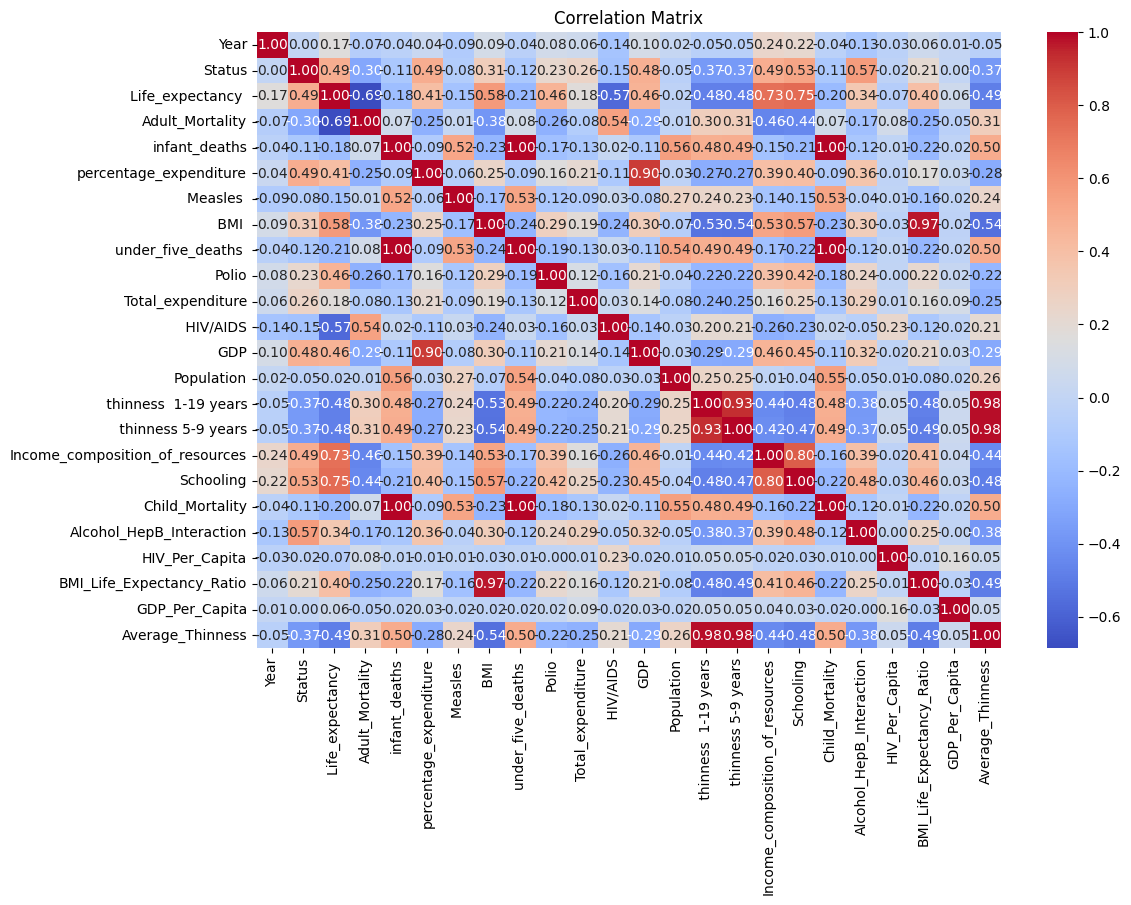

Highly Correlated Features to Drop: {'BMI_Life_Expectancy_Ratio', 'Average_Thinness', 'Child_Mortality', ' thinness 5-9 years', 'under_five_deaths '}

Feature Importances:
                            Feature  Importance
9                          HIV/AIDS    0.543546
13  Income_composition_of_resources    0.262272
2                   Adult_Mortality    0.099385
6                              BMI     0.021118
14                        Schooling    0.013801
12             thinness  1-19 years    0.011335
3                     infant_deaths    0.007944
15         Alcohol_HepB_Interaction    0.007211
8                 Total_expenditure    0.005881
0                              Year    0.005412
7                             Polio    0.005113
10                              GDP    0.003747
4            percentage_expenditure    0.002829
17                   GDP_Per_Capita    0.002628
5                          Measles     0.002614
16                   HIV_Per_Capita    0.002574
11          

ValueError: Input X contains NaN.
SelectKBest does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [154]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectKBest, f_regression


data_selected = data[numerical_cols]

correlation_matrix = data_selected.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix")
plt.show()

high_corr_features = set()
for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        if abs(correlation_matrix.iloc[i, j]) > 0.9:
            colname = correlation_matrix.columns[i]
            high_corr_features.add(colname)

print("Highly Correlated Features to Drop:", high_corr_features)

data_selected = data_selected.drop(columns=high_corr_features, errors='ignore')

X = data_selected.drop(columns=['Life_expectancy '])
y = data_selected['Life_expectancy ']

#Model
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X, y)


feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importances:")
print(feature_importances)

top_features = feature_importances['Feature'].head(10).tolist()
data_selected = data_selected[top_features + ['Life_expectancy ']]

selector = SelectKBest(score_func=f_regression, k=10)
X_new = selector.fit_transform(X, y)

selected_feature_indices = selector.get_support(indices=True)
selected_features = X.columns[selected_feature_indices]

print("\nTop Features from Statistical Tests:")
print(selected_features)

# Update dataset with selected features
data_selected = data_selected[selected_features.tolist() + ['Life_expectancy ']]

In [159]:
features = [' HIV/AIDS', 'Income_composition_of_resources', 'Adult_Mortality', ' BMI ']
# Updated feature names to match the actual column names in the DataFrame.
data_selected_new = data[features]

In [162]:
data[features]

,HIV/AIDS,Income_composition_of_resources,Adult_Mortality,BMI
0,0.1,0.479,263,19.1
1,0.1,0.476,271,18.6
2,0.1,0.470,268,18.1
3,0.1,0.463,272,17.6
4,0.1,0.454,275,17.2
...,...,...,...,...
2456,33.6,0.407,723,27.1
2457,36.7,0.418,715,26.7
2458,39.8,0.427,73,26.3
2459,42.1,0.427,686,25.9


# **Linear Regression**

In [179]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score


features = [' HIV/AIDS', 'Income_composition_of_resources', 'Adult_Mortality', ' BMI ']
data_selected_new = data[features]

X = data[features]
y = data['Life_expectancy ']

X_train,X_test,y_train,y_test = train_test_split(X,y, random_state = 42, test_size = 0.2)

Lm = LinearRegression()
Lm.fit(X_train, y_train)

y_pred = Lm.predict(X_test)


rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Root Mean Squared Error (RMSE):", rmse)
print("R-squared (R2) Score:", r2)

Root Mean Squared Error (RMSE): 4.790506635133855
R-squared (R2) Score: 0.746086648856628

Feature Coefficients:
                           Feature  Coefficient
0                         HIV/AIDS    -0.448438
1  Income_composition_of_resources    21.349044
2                  Adult_Mortality    -0.019997
3                             BMI      0.082454


In [184]:
new_sample = pd.DataFrame({
    ' HIV/AIDS': [1.5],
    'Income_composition_of_resources': [0.7],
    'Adult_Mortality': [150],
    ' BMI ': [20]
})
predicted_life_expectancy = Lm.predict(new_sample)
print(f"\nPredicted Life Expectancy for New Sample: {predicted_life_expectancy[0]:.2f}")


Predicted Life Expectancy for New Sample: 69.78
